# MATH-509: Lab 06

**Ben Miller**

[PLACEHOLDER_FOR_NOTEBOOK_LINK]



## Getting Started

Follow the instructions below to copy this notebook and to perform some initial setup.

1. Copy this notebook by selecting `File > Save a copy in Drive`.
2. A new window should open for the copied notebook. Move the new notebook to your course folder in Google Drive by selecting `File > Move` and then selecting the desired folder.
3. Update the name of the notebook by removing "Copy of" and replacing "Username" with your actual username.
4. Update the first cell in the notebook by replacing "Student Name" with your actual name.
5. Do not edit the line that says `PLACEHOLDER_FOR_NOTEBOOK_LINK`. This will be used by the [notebook renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool to insert a link to your Colab notebook.
6. Enable link sharing for your notebook.

## Double-Check Your Notebook

Please make sure that you are working in your own copy of the notebook before you proceed. Work completed in the template notebook will not be saved! Take a look at the URL for this notebook. If you see the string `1Hh9w1HqTiiTZs7iotM9ujwE7WUrZ-WWu`, then you are in the template, NOT your own copy.

## Import Statements

Run the cell below to import the NumPy and Matplotlib packages.  **No other packages are to be used in this assignment.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)

## Datasets

Several arrays have been created to store the datasets that you will be working with in this lab. Running the cell below will import those arrays into your workspace. Run that cell now. We will describe the imported arrays in a moment.


In [2]:
%%capture
!git clone https://github.com/drbeane/MATH_509.git
from MATH_509.data import *

The following arrays have been created in your workspace: `x1`, `y1`, `X2`, `X3`, `X3_ones`, and `y3`. Descriptions of these arrays are provided below.

**Dataset 1 (Used in Problems 1 - 5):** Arrays `x1` and `y1` are 1D arrays. The array `x1` represents a single feature and `y1` represents a sample of a target variable. Both arrays contain 1000 values.

**Dataset 2 (Used in Problem 6):** Array `X2` is a 2D array with 1000 rows and 100 columns. It represents a feature array for a dataset with 100 features. We will use this array to explore PCA in Problem 6.

**Dataset 3 (Used in Problems 7 and 8):** Array `X3` is a 2D array with 100 rows and 5 columns. It represents a feature array for a dataset with 5 features. Array `y3` is a 1D array containing the target values for the same 100 observations as contained in `X3`. Array `X3_ones` is identical to `X3`, but contains an additioanl column containing only 1s.

**Note:** We are using the convention that 1D arrays will be named using lowercase letters and 2D arrays will be named using uppercase letters. Take note of this as you are using the arrays throughout the lab.

Run the cell below to confirm the shape of these arrays.


In [3]:
print(f'Array x1 has shape:      {x1.shape}')
print(f'Array y1 has shape:      {y1.shape}')
print(f'Array X2 has shape:      {X2.shape}')
print(f'Array X3 has shape:      {X3.shape}')
print(f'Array X3_ones has shape: {X3_ones.shape}')
print(f'Array y3 has shape:      {y3.shape}')

Array x1 has shape:      (1000,)
Array y1 has shape:      (1000,)
Array X2 has shape:      (1000, 100)
Array X3 has shape:      (100, 5)
Array X3_ones has shape: (100, 6)
Array y3 has shape:      (100,)


# Problem 1 - Descriptive Statistics

In this problem, you will calculate the mean, standard deviation, and range of a sample. We will also calculate the **coefficient of variation**. The coefficient of variation $CV$ for a sample is a unitless measure of variability that is calculated by dividing the standard deviation of the sample by the mean. The formula is provoded below.

$$CV = \frac{s_X}{\bar x}$$


### Part 1.A

Use the cell below to calculate the mean, standard deviation, range, and coefficient of variation for the sample stored in `x1`. Store each value in a variable. **You do not need to print anything in this cell.**


In [4]:
mean_x1 = np.mean(x1)
std_x1 = np.std(x1, ddof=1)
range_x1 = np.max(x1) - np.min(x1)
coeff_x1 = std_x1 / mean_x1

### Part 1.B

Replace the double underscores in the cell below with the appropriate variables and then run the cell to display the statistics you have calculated.

In [5]:
print(f'Sample mean:    {mean_x1}')
print(f'Sample std dev: {std_x1}')
print(f'Coef of Var:    {coeff_x1}')
print(f'Range:          {range_x1}')

Sample mean:    503.409
Sample std dev: 98.16070110916203
Coef of Var:    0.19499194712284054
Range:          701


# Problem 2 - IQR and Outliers

Quartiles are sometimes used to identify outliers in a sample. The standard method of doing so is described below.

1. Calculate the first and third quartiles, $Q_1$ and $Q_3$.
2. Calculate the **interquartile range** ($IQR$) using the formula: $IQR = Q_3 - Q_1$.
3. Calculate the **lower fence** ($LF$) using the formula: $LF = Q_1 - 1.5 \cdot IQR$.
4. Calculate the **upper fence** ($LF$) using the formula: $UF = Q_3 + 1.5 \cdot IQR$.
5. Any observation below the lower fence or above the upper fence is considered an outlier.




### Part 2.A

Use the cell below to calculate the $IQR$, lower fence, and upper fence for the sample in `x1`. Then print each of these values.

In [6]:
q1 = np.percentile(x1, q=25)
q3 = np.percentile(x1, q=75)

IQR = q3 - q1
LF = q1 - (1.5 * IQR)
UF = q3 + (1.5 * IQR)

print(IQR)
print(LF)
print(UF)

131.25
242.125
767.125


### Part 2.B

You will now select and count the outliers in `x1`.

Start by creating a Boolean selection array (you might name this `sel`). This array should have the same length as `x1` and should contain `True` for every entry where the corresponding value in `x1` is less than the lower fence or greater than the upper fence. You will need to use the "or" Boolean operator `|`. This should only require one line of code. **No loops or list comprehensions should be used.**

Use the selection array to select the outliers from `x1`.

Print the number of outliers, and then print the outliers.

In [7]:
sel = (x1 < LF) | (x1 > UF)
outliers = x1[sel]

print(len(outliers))
print(outliers)

9
[220 803 221 895 220 832 230 194 233]


# Problem 3 - z-Scores and Outliers

Z-scores are also sometimes used to identify outliers. One approach is to declare any observation with a z-score with an absolute value greater than 3 to be an outlier.


### Part 3.A

Use the cell below to calculate the z-scores for the observations in the sample stored in `x1`. Then print the minimum and maximum z-scores.

In [8]:
z_scores = (x1 - mean_x1) / std_x1

print(np.min(z_scores))
print (np.max(z_scores))

-3.1520659133833413
3.9892848724106154


### Part 3.B

Create a Boolean selection array to select the observations that have a z-score that is less than -3 or greater than 3. This will require you to use either the "or" operation `|` or the absolute value function. **No loops or list comprehensions should be used.**

Use the selection array to select the outliers from `x1`.

Print the number of outliers, and then print the outliers.

In [9]:
sel = (z_scores > 3) | (z_scores < -3)

outliers = x1[sel]

print(len(outliers))
print(outliers)

4
[803 895 832 194]


# Problem 4 - Confidence Interval

A sample mean provides an estimate for the mean of the population from which the sample was drawn. When working with estimates, it is often useful to be able to expand the estimate into an interval that is likely to contain the true value being estimated. Such an interval is called a **confidence interval**. A 95% confidence interval, for example, is an interval that we believe has a 95% chance of containing the true value being estimated.

To form a confidence interval, we first need to calculate a quantity known as the **standard error** ($SE$) for the sample. The formula for the standard error is provided below. The variable $n$ refers to the size of the sample.

$$SE = \frac{s_X}{\sqrt{n}}$$

After calculating the standard error, a 95% confidence interval can be found by calculating the lower fence ($LF$) and upper fence ($UF$) of the interval, as shown below.

$$LF = \bar x - 1.96 \cdot SE$$

$$UF = \bar x + 1.96 \cdot SE$$

The confidence intervalue is then given by $(LF, UF)$.

### Part 4.A

Use the cell below to calculate the standard error for the sample `x1`. You can (and should) reuse variables created in Problem 1. Print the standard error.

In [10]:
n = len(x1)
standard_error = std_x1 / (n**(1/2))

print(standard_error)

3.1041139222396854


### Part 4.B
Calculate the lower and upper fences for the 95% confidence interval. Print both values using separate print statements. You can (and should) reuse variables that you have created previously in the notebook.

In [11]:
LF = mean_x1 - 1.96 * standard_error
UF = mean_x1 + 1.96 * standard_error

print(LF)
print(UF)

497.3249367124102
509.4930632875898


# Problem 5 - Log Transformation

Linear regression is an appropriate model to use when the relationship between the target variable and feature variable is linear. When the relationship is non-linear, we often need to peform a transformation on one or both variables to produce a linear relationship. We will explore that idea in this problem.




### Part 5.A

Use the cell below to create a scatter plot demonstrating the relationship between the values `x1` and `y1`. The values of `x1` should be plotted along the horizontal axis and `y1` should be plotted along the vertical axis.

Create your plot according to the following specifications:
* Set a figure size of `[6,3]`.
* Set `alpha=0.5` and `zorder=2` when calling `plt.scatter()`.
* Add a grid to the plot.

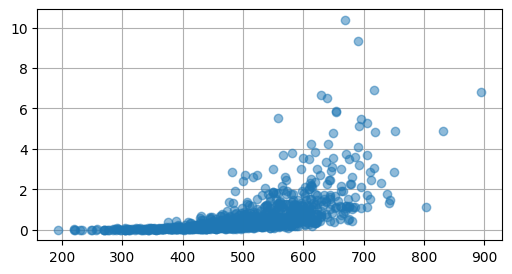

In [12]:
plt.figure(figsize=[6,3])
plt.scatter(x1, y1, alpha=0.5, zorder=2)
plt.grid()
plt.show()

### Part 5.B

The relationship between `x1` and `y1` appears to be nonlinear. This can sometimes be remedied by calculating the natural logarithm of one or both variables. Use the cell below to take the natural log of `x1` and `y1`, storing the results in variables. Then create a scatter plot using the logged values. Use the same specifications as described in 5.A.

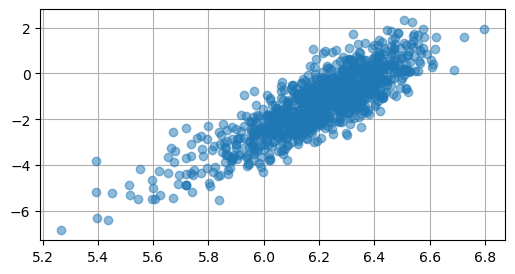

In [13]:
log_x1 = np.log(x1)
log_y1 = np.log(y1)

plt.figure(figsize=[6,3])
plt.scatter(log_x1, log_y1, alpha=0.5, zorder=2)
plt.grid()
plt.show()

### Part 5.C

Use the cell below to perform the following steps:
1. Calculate the correlation between `x1` and `y1`.
2. Calculate the correlation between the log of `x1` and the log of `y1`.
3. Use the correlation between `x1` and `y1` to find the r-squared value for this relationship.
4. Use the correlation between the log of `x1` and log of `y1` to find the r-squared value for this relationship.
5. Print both r-sqared values rounded to 4 decimal places. Use two separate print statements for this.

You should see that the r-squared value for the logged samples is over twice that of the original samples

In [14]:
std_y1 = np.std(y1)
std_logx1 = np.std(log_x1)
std_logy1 = np.std(log_y1)

# Calculate the Covariance matrices
C_xy = np.cov([x1, y1])
C_logxy = np.cov([log_x1, log_y1])

# Find the covariances for x1,y1 and log_x1,log_y1
covariance_xy = C_xy[0, 1]
covariance_logxy = C_logxy[0, 1]

# Calculate the correlations
# r_xy = s_xy / (s_x * s_y)
correlation_xy = covariance_xy / (std_x1 * std_y1)
correlation_logxy = covariance_logxy / (std_logx1 * std_logy1)

# Calculate R squared
r2_xy = correlation_xy ** 2
r2_logxy = correlation_logxy ** 2

print(round(r2_xy, 4))
print(round(r2_logxy, 4))


0.3514
0.7279


# Problem 6 - PCA

In this problem, we will be perfroming PCA on the feature array stored in `X2`. Please refer to the lesson titled "Principal Compoent Analysis" in Canvas for details.  


### Part 6.A

Use the cell below to perfrom the following tasks:

1. Center the feature array `X2` to create the array `M` mentioned in the lesson on PCA.
2. Calculate the covariance matrix for `M`.
3. Find the eigenvalues and eigenvectors for the covariance matrix. **Use `eigh()` for this rather than `eig()`**.
4. Flip the order of the eigenvalues and the eigenvectors as described in the lesson on Canvas.
5. Print the shape of the covariance matrix. This should be `(100,100)`.
6. Print the first 10 eigenvalues (all on one line), rounded to 2 decimal places.

In [15]:
M = X2 - X2.mean(axis=0)
C = np.cov(M.T)
evals, W = np.linalg.eigh(C)
evals = np.flip(evals)
W = np.flip(W, axis=1)
print(C.shape)
print(np.round(evals[:10], 2))

(100, 100)
[199.36 137.24  90.75  85.    65.44  47.26  31.05  28.53  20.55  15.69]


### Part 6.B

Use the cell below to perform the following tasks:

1. Reorder the columns of the eigenvector matrix in decreasing order of eigenvalue. Refer to the PCA notes for details.
2. Calculate the transformed feature values, $Z$.
3. Use slicing to print the values in the first 5 rows and first 5 columns of $Z$, rounded to 2 decimal places.

In [16]:
# the eigenvector matrix's columns were flipped in the previous cell for step 4
Z = M @ W
print(np.round(Z[:5, :5], 2))

[[  3.35  20.01  -6.31  -3.73  -1.33]
 [-24.8   -1.27  -4.7   -3.82  12.15]
 [ -3.92  -7.03 -18.06   3.25  13.54]
 [ 15.55   9.17  -2.28   1.09  -3.22]
 [ 20.33 -16.78 -14.79   6.09  -0.47]]


### Part 6.C

Use the cell below to perfrom the following tasks:

1. Calculate the explained variance ratios for each of the transformed feature values.
2. Print the explained variance ratios for the first 10 transformed features, all on one line, and rounded to 3 decimal places.
3. Print the sum of the explained variance ratios for the first 10 transformed features, rounded to 3 decimal places.

In [17]:
explained_variance = evals / evals.sum()
print(np.round(explained_variance[:10], 3))
print(np.round(np.sum(explained_variance[:10]), 3))

[0.232 0.159 0.105 0.099 0.076 0.055 0.036 0.033 0.024 0.018]
0.837


# Problem 7 - Coefficient of Determination (Part 1)

In Problems 7 and 8, we will explore the coefficient of determination, or r-squared value. We will calculate this value in two different ways for the dataset stored in `y3`, `X3`, and `X3_ones`. Please refer to the lesson titled "Coefficient of Determination" in Canvas for details.  

In Problem 7, we will calculate $r^2$ by building the model, generating predictions, and then calculating $SST$ and $SSE$.



### Part 7.A

Use the matrix formula shown below to find the optimal parameter values for this regression problem. Note that the matrix $X$ mentioned in this formula should have an additional first column containing only 1's. This matrix has been provided to you as `X3_ones`.  

$$
\hat \beta =
\begin{bmatrix}
\hat \beta_0 \\
\hat \beta_1 \\
\vdots \\
\hat \beta_K \\
\end{bmatrix}
=
\left(X^T \cdot X \right ) ^{-1} \cdot X^T \cdot y
$$

Print the optimal beta values on one line, rounded to 2 decimal places.

In [18]:
B = np.linalg.inv(X3_ones.T @ X3_ones) @ X3_ones.T @ y3

print(np.round(B, 2))

[ 33.39  13.52  30.99   2.28 -26.39 -13.31]


### Part 7.B

Use the model to generate predications $\hat y$ using the matrix formula shown below. Again, note that the matrix $X$ appearing in this formula is expected to contain a column of ones, as in `X3_ones`.

$$\hat y = X \cdot \hat \beta$$

After calculating your predictions, calculate $SSE$ and $SST$ for the model. Use NumPy operations instead of loops or list comprehensions.

Then use $SSE$ and $SST$ to calculate $r^2$. Print the value you have found for $r^2$ rounded to 4 decimal places.

In [19]:
y_hat = X3_ones @ B
SSE = np.sum((y3 - y_hat) ** 2)
SST = np.sum((y3 - np.mean(y3)) ** 2)

r_squared = 1 - (SSE / SST)

print(round(r_squared, 4))

0.8149


# Problem 8 - Coefficence of Determination (Part 2)

In this problem, we will calculate the coefficient of determination using the matrix formulas discussed in the corresponding lesson.



### Part 8.A

Use the cell below to calculate the matrices $R_Y$ and $R_X$ described in the lesson. Print the shape of each of these matrices. If calculated correctly, $R_Y$ should have shape `(5,)` and $R_X$ should have shape `(5,5)`.

In [20]:
M = np.vstack([y3, X3.T])
R = np.corrcoef(M)
RY = R[1:, 0]
RX = R[1:, 1:]

print(RY.shape)
print(RX.shape)

(5,)
(5, 5)


### Part 8.B

Use the matrix formula involving $R_Y$ and $R_X$ to calculate $r^2$ and then print this value rounded to 4 decimal places. You should get the essentially the same result as in Problem 7. There might be an extremely small difference due to rounding issues related to how NumPy performed the calculations.

In [21]:
r_squared = RY @ np.linalg.inv(RX) @ RY.T

print(round(r_squared, 4))

0.8149


# Submission Instructions

1. Perform a Restart and Run All by clicking **Runtime > Restart session and run all**.
2. Copy the link to your notebook by clicking **Share > Copy Link**.
3. Paste the copied link into the `notebook_url` field in the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool and then execute the cell to render the notebook.
4. The Notebook Renderer will open up a save file dialog. Save the resulting HTML file to your local machine.
5. Submit the HTML file to Canvas.
